# FundSight Mutual Fund Analytics

## Day 3 - Exploratory Data Analysis (EDA)

### Objectives

This notebook performs exploratory data analysis on the cleaned mutual fund dataset generated during the ETL process.

The analysis focuses on:

- Daily NAV trends
- AUM Growth
- SIP Inflows
- Category-wise inflows
- Investor demographics
- Geographic distribution
- Folio growth
- NAV return correlations
- Sector allocation

**Tools Used**

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
from pathlib import Path

# Project root
ROOT = Path.cwd().parent

# Processed data
nav = pd.read_csv(ROOT / "data" / "processed" / "clean_nav.csv")
performance = pd.read_csv(ROOT / "data" / "processed" / "clean_performance.csv")
transactions = pd.read_csv(ROOT / "data" / "processed" / "clean_transactions.csv")

# Raw data
aum = pd.read_csv(ROOT / "data" / "raw" / "03_aum_by_fund_house.csv")
sip = pd.read_csv(ROOT / "data" / "raw" / "04_monthly_sip_inflows.csv")
category = pd.read_csv(ROOT / "data" / "raw" / "05_category_inflows.csv")
folio = pd.read_csv(ROOT / "data" / "raw" / "06_industry_folio_count.csv")
portfolio = pd.read_csv(ROOT / "data" / "raw" / "09_portfolio_holdings.csv")

print("✅ Data loaded successfully!")

✅ Data loaded successfully!


In [3]:
datasets = {
    "NAV": nav,
    "Performance": performance,
    "Transactions": transactions,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Portfolio": portfolio
}

for name, df in datasets.items():
    print("=" * 60)
    print(f"{name} Dataset")
    print("=" * 60)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nFirst 5 Rows:")
    display(df.head())
    print("\n")

NAV Dataset
Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']

First 5 Rows:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639




Performance Dataset
Shape: (40, 20)

Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'anomaly_flag']

First 5 Rows:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly_flag
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False




Transactions Dataset
Shape: (32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

First 5 Rows:


...

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0




Folio Dataset
Shape: (21, 6)

Columns:
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

First 5 Rows:


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48




Portfolio Dataset
Shape: (322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

First 5 Rows:


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [4]:
from pathlib import Path

ROOT = Path.cwd().parent

CHARTS_DIR = ROOT / "charts"

CHARTS_DIR.mkdir(exist_ok=True)

print("Charts folder created successfully.")

Charts folder created successfully.


# 1. NAV Trend Analysis

### Objective

Visualize the daily NAV movement of all mutual fund schemes between 2022 and 2026.

The highlighted regions represent:

- Green → 2023 Bull Run
- Red → 2024 Market Correction

In [5]:
nav_df = nav.merge(
    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

nav_df["date"] = pd.to_datetime(nav_df["date"])

display(nav_df.head())

,amfi_code,date,nav,scheme_name,fund_house,category
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap


In [6]:
import plotly.express as px

# Get top 8 schemes by AUM to keep the chart clean and professional
top_schemes = performance.sort_values(by="aum_crore", ascending=False).head(8)["scheme_name"].tolist()
nav_filtered = nav_df[nav_df["scheme_name"].isin(top_schemes)].copy()

# Sort by date for proper cumulative tracking
nav_filtered = nav_filtered.sort_values(by=["scheme_name", "date"])

# Normalize NAV: make each scheme start at exactly 100 on its first date
nav_filtered["normalized_nav"] = nav_filtered.groupby("scheme_name")["nav"].transform(
    lambda x: (x / x.iloc[0]) * 100 if len(x) > 0 else 100
)

# Custom high-end corporate palette
plotly_palette = ["#1e3a8a", "#0d9488", "#4f46e5", "#f97316", "#06b6d4", "#8b5cf6", "#ec4899", "#10b981"]

fig = px.line(
    nav_filtered,
    x="date",
    y="normalized_nav",
    color="scheme_name",
    color_discrete_sequence=plotly_palette,
    title="Daily Cumulative Growth of Top 8 Mutual Fund Schemes (Base 100, 2022–2026)",
    labels={
        "date": "Date",
        "normalized_nav": "Growth Value (Base 100)",
        "scheme_name": "Scheme"
    }
)

# Customize hover info to show both growth % and absolute NAV
fig.update_traces(
    hovertemplate="<b>%{fullData.name}</b><br>Date: %{x}<br>Growth Value: %{y:.1f} (Base 100)<extra></extra>"
)

# Add range selector slider buttons (YTD, 1Y, 2Y, All) with custom styling
fig.update_layout(
    template="plotly_white",
    width=1200,
    height=650,
    title={
        "text": "<b>Growth of ₹100 Investment in Top 8 Schemes (2022–2026)</b>",
        "y": 0.95,
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 18, "color": "#1e293b", "family": "Segoe UI, Helvetica, Arial"}
    },
    xaxis=dict(
        showgrid=True,
        gridcolor="#f1f5f9",
        tickfont=dict(color="#475569", size=10),
        rangeselector=dict(
            buttons=list([
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="YTD", step="year", stepmode="todate"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(count=2, label="2Y", step="year", stepmode="backward"),
                dict(step="all", label="ALL")
            ]),
            font=dict(size=10, color="#1e293b"),
            bgcolor="#f1f5f9",
            activecolor="#e2e8f0",
            bordercolor="#cbd5e1",
            borderwidth=1
        ),
        rangeslider=dict(visible=True, thickness=0.08, bgcolor="#f8fafc")
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="#f1f5f9",
        tickfont=dict(color="#475569", size=10),
        tickprefix="₹"
    ),
    legend=dict(
        font=dict(size=8, color="#475569"),
        bgcolor="rgba(255, 255, 255, 0.95)",
        bordercolor="#e2e8f0",
        borderwidth=1,
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    ),
    margin=dict(t=100, b=100, l=60, r=250)
)

fig.show()
fig.write_image(CHARTS_DIR / "nav_trend.png", scale=2)
print("nav_trend.png saved successfully")


nav_trend.png saved successfully


### Insight 1

The majority of equity-oriented mutual fund schemes experienced a strong upward NAV movement throughout 2023, reflecting the broader equity market rally.

A temporary correction during early 2024 is visible before schemes resumed their long-term growth trend.

# 2. AUM Growth Analysis

### Objective

Analyze the Assets Under Management (AUM) growth of major fund houses between 2022 and 2025.

This visualization compares yearly AUM values and highlights SBI Mutual Fund's industry-leading AUM.

In [7]:
# Prepare AUM Data

aum_df = aum.copy()

aum_df["date"] = pd.to_datetime(aum_df["date"])

aum_df["year"] = aum_df["date"].dt.year

display(aum_df.head())

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


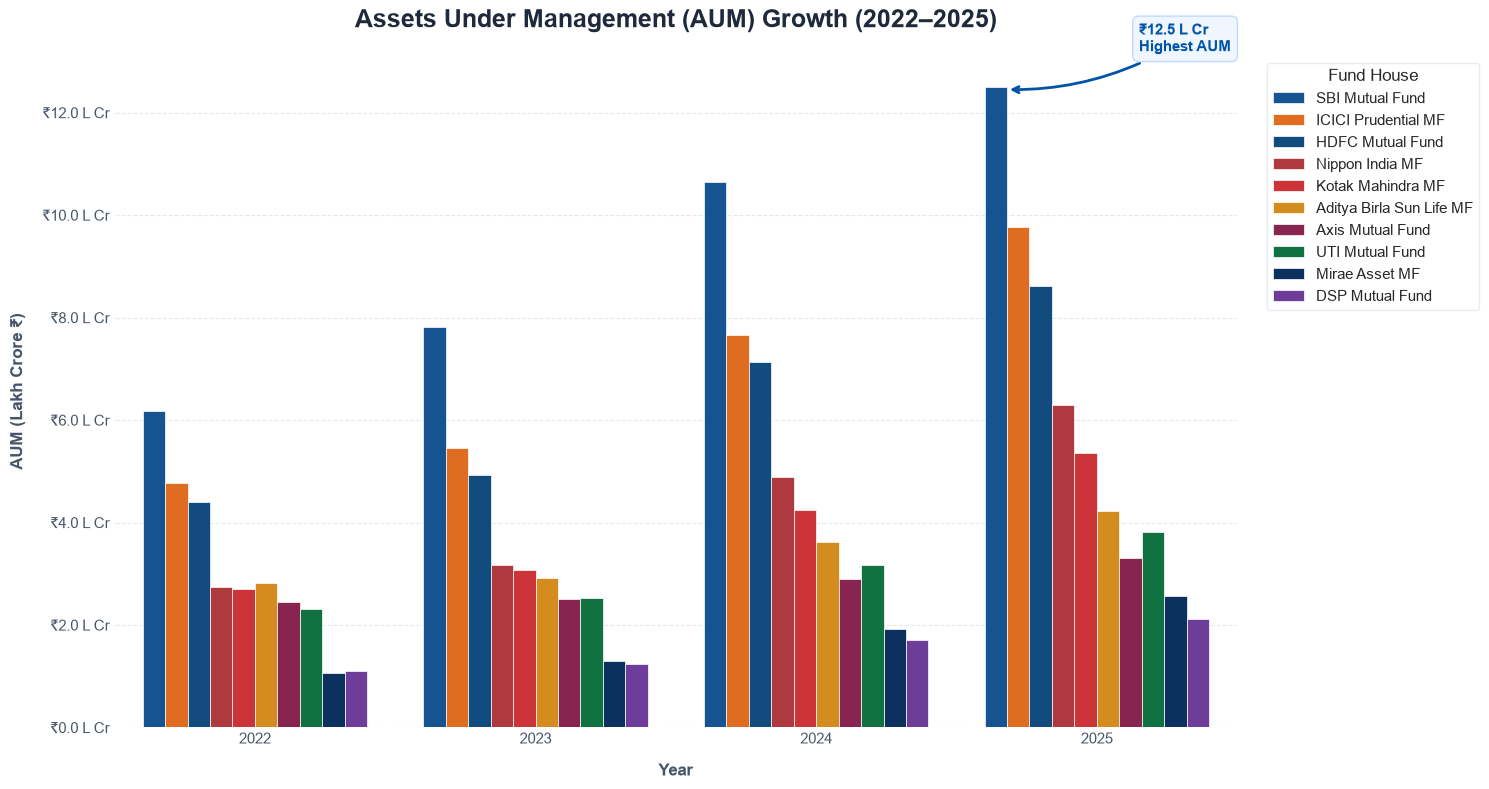

aum_growth.png saved successfully


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Custom premium styling
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(15, 8), facecolor="white")
ax.set_facecolor("white")

# Define premium brand colors for the fund houses
brand_palette = {
    "SBI Mutual Fund": "#0054A6",          # SBI Blue
    "ICICI Prudential MF": "#FF6600",      # ICICI Orange
    "HDFC Mutual Fund": "#004C8F",         # HDFC Blue
    "Nippon India MF": "#C1272D",          # Nippon Red
    "Kotak Mahindra MF": "#E61A22",        # Kotak Red
    "Aditya Birla Sun Life MF": "#F39200", # ABSL Gold/Yellow
    "Axis Mutual Fund": "#97144D",         # Axis Burgundy
    "UTI Mutual Fund": "#008240",          # UTI Green
    "Mirae Asset MF": "#002F6C",           # Mirae Navy
    "DSP Mutual Fund": "#6F2DA8"           # DSP Purple
}

# Plot
sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house",
    palette=brand_palette,
    errorbar=None,
    ax=ax,
    edgecolor="white",
    linewidth=0.5
)

# Custom title and labels
ax.set_title("Assets Under Management (AUM) Growth (2022–2025)", fontsize=18, fontweight="bold", pad=20, color="#1e293b")
ax.set_xlabel("Year", fontsize=12, fontweight="bold", labelpad=12, color="#475569")
ax.set_ylabel("AUM (Lakh Crore ₹)", fontsize=12, fontweight="bold", labelpad=12, color="#475569")

# Format ticks and grid
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"₹{x:.1f} L Cr"))
ax.tick_params(colors="#475569", labelsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cbd5e1')
ax.set_axisbelow(True)

# Remove outer spines for minimalist aesthetic
sns.despine(ax=ax, left=True, bottom=True)

# Custom legend styling
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#e2e8f0",
    title="Fund House",
    title_fontsize="12",
    fontsize="11"
)

# Annotation for SBI Mutual Fund in 2025
ax.annotate(
    "₹12.5 L Cr\nHighest AUM",
    xy=(2.68, 12.45),          # 2025 SBI bar
    xytext=(3.15, 13.2),       # position of text
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.15",
        color="#0054A6",
        lw=2
    ),
    fontsize=11,
    color="#0054A6",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="#eff6ff", ec="#bfdbfe", lw=1)
)

plt.tight_layout()

plt.savefig(CHARTS_DIR/"aum_growth.png", dpi=300)
plt.show()
print("aum_growth.png saved successfully")


## Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) across all observed years, demonstrating its strong market leadership.

Most major fund houses exhibited steady AUM growth between 2022 and 2025, reflecting increasing investor participation in mutual funds.

# 3. SIP Inflow Trend Analysis

### Objective

Analyze the monthly SIP inflow trend from January 2022 to December 2025 and highlight the record inflow achieved in December 2025.

In [9]:
sip_df = sip.copy()

sip_df["month"] = pd.to_datetime(sip_df["month"])

display(sip_df.head())

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [10]:
print(sip_df.tail())

        month  sip_inflow_crore  active_sip_accounts_crore  \
43 2025-08-01             28265                       8.85   
44 2025-09-01             29361                       9.00   
45 2025-10-01             29529                       9.10   
46 2025-11-01             30200                       9.20   
47 2025-12-01             31002                       9.35   

    new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
43                   9.80               15.18           20.04  
44                  10.50               15.38           19.80  
45                   9.45               15.55           16.61  
46                   9.10               15.72           19.27  
47                   9.80               15.90           17.17  


In [11]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

sip_df = sip.copy()
sip_df["month"] = pd.to_datetime(sip_df["month"])
sip_df = sip_df.sort_values(by="month")

# Calculate YoY Growth Rate
sip_df["yoy_growth"] = sip_df["sip_inflow_crore"].pct_change(12) * 100

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add stepped area trace for SIP Inflow
fig.add_trace(
    go.Scatter(
        x=sip_df["month"],
        y=sip_df["sip_inflow_crore"],
        name="SIP Inflow (₹ Crore)",
        line=dict(color="#0d9488", width=3, shape="hv"),
        fill="tozeroy",
        fillcolor="rgba(13, 148, 136, 0.06)",
        mode="lines"
    ),
    secondary_y=False
)

# Add YoY Growth rate trace
yoy_valid = sip_df.dropna(subset=["yoy_growth"])
fig.add_trace(
    go.Scatter(
        x=yoy_valid["month"],
        y=yoy_valid["yoy_growth"],
        name="YoY Growth Rate (%)",
        line=dict(color="#f97316", width=2, dash="dash"),
        mode="lines"
    ),
    secondary_y=True
)

# Highlight All-Time High Inflow
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="<b>All-Time High Inflow</b><br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.0,
    arrowwidth=1.5,
    arrowcolor="#0f766e",
    ax=-90,
    ay=-40,
    font=dict(color="#0f766e", size=10, family="Segoe UI"),
    bgcolor="#f0fdf4",
    bordercolor="#bbf7d0",
    borderwidth=1,
    borderpad=4
)

# Format axes and layout
fig.update_layout(
    template="plotly_white",
    width=1000,
    height=500,
    title={
        "text": "<b>Monthly SIP Inflow Volume vs. Growth Momentum (2022–2025)</b>",
        "y": 0.94,
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 16, "color": "#1e293b", "family": "Segoe UI, Helvetica, Arial"}
    },
    xaxis=dict(
        showgrid=True,
        gridcolor="#f1f5f9",
        tickfont=dict(color="#475569")
    ),
    yaxis=dict(
        title=dict(
            text="<b>SIP Inflow (₹ Crore)</b>",
            font=dict(color="#0d9488", size=12)
        ),
        showgrid=True,
        gridcolor="#f1f5f9",
        tickfont=dict(color="#475569"),
        tickprefix="₹",
        tickformat=",.0f"
    ),
    yaxis2=dict(
        title=dict(
            text="<b>YoY Growth Rate (%)</b>",
            font=dict(color="#f97316", size=12)
        ),
        showgrid=False,
        tickfont=dict(color="#475569"),
        ticksuffix="%"
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1.0
    ),
    margin=dict(t=100, b=50, l=60, r=60)
)

fig.show()
fig.write_image(CHARTS_DIR / "sip_inflow_trend.png", scale=2)
print("sip_inflow_trend.png saved successfully")


sip_inflow_trend.png saved successfully


In [12]:
fig.write_image(CHARTS_DIR / "sip_trend.png")

print("✅ sip_trend.png saved successfully!")

✅ sip_trend.png saved successfully!


## Insight 3

Monthly SIP inflows showed a strong upward trajectory from 2022 to 2025, indicating growing retail investor participation in mutual funds.

The highest monthly SIP inflow of **₹31,002 Crore** was recorded in **December 2025**, highlighting continued confidence in long-term systematic investing.

# 4. Category Inflow Heatmap

### Objective

Visualize monthly net inflows across different mutual fund categories using a heatmap.

This helps identify which categories attracted the highest investments during different months.

In [13]:
category_df = category.copy()

category_df["month"] = pd.to_datetime(category_df["month"])

display(category_df.head())

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [14]:
heatmap_data = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

display(heatmap_data.head())

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


In [15]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Pivot
heatmap_data = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Sort columns chronologically
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)

z_values = heatmap_data.values
y_labels = list(heatmap_data.index)
x_labels = [m.strftime("%b %Y") for m in heatmap_data.columns]

# Construct text values with dynamic HTML coloring based on cell intensity
text_values = []
for row in z_values:
    text_row = []
    for val in row:
        color = "white" if val > 15000 else "#334155"
        if val >= 1000:
            text_row.append(f"<span style='color: {color};'>₹{val/1000:.1f}K Cr</span>")
        else:
            text_row.append(f"<span style='color: {color};'>₹{val:.0f} Cr</span>")
    text_values.append(text_row)

# Custom color palette: Slate grey to Teal
colorscale = [
    [0.0, '#f8fafc'],      # Slate 50
    [0.1, '#f1f5f9'],      # Slate 100
    [0.3, '#ccfbf1'],      # Teal 100
    [0.6, '#2dd4bf'],      # Teal 400
    [0.8, '#0d9488'],      # Teal 600
    [1.0, '#115e59']       # Teal 800
]

fig = go.Figure(data=go.Heatmap(
    z=z_values,
    x=x_labels,
    y=y_labels,
    text=text_values,
    texttemplate="%{text}",
    textfont={"size": 10, "family": "Segoe UI, Helvetica, Arial", "weight": "bold"},
    colorscale=colorscale,
    showscale=True,
    colorbar=dict(
        title=dict(text="Net Inflow (₹ Crore)", side="right"),
        thickness=15,
        len=0.8
    ),
    xgap=2,
    ygap=2
))

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600,
    title={
        "text": "<b>Monthly Net Inflows Across Fund Categories (2022–2025)</b><br><span style='font-size:12px;color:#64748b;'>Annotated grid showing exact monthly net inflow volumes</span>",
        "y": 0.95,
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 18, "color": "#1e293b", "family": "Segoe UI, Helvetica, Arial"}
    },
    xaxis=dict(
        tickmode="array",
        tickvals=x_labels,
        ticktext=x_labels,
        tickangle=40,
        showgrid=False,
        side="bottom"
    ),
    yaxis=dict(
        showgrid=False,
        autorange="reversed"
    ),
    margin=dict(t=100, b=80, l=150, r=80)
)

fig.show()
fig.write_image(CHARTS_DIR / "category_heatmap.png", scale=2)
print("category_heatmap.png saved successfully")


category_heatmap.png saved successfully


## Insight 4

- Liquid funds consistently recorded the highest monthly net inflows, reflecting strong institutional and short-term treasury investments.

- Equity-oriented categories such as Large & Mid Cap, Mid Cap, and Small Cap also maintained healthy inflows, indicating sustained investor confidence in long-term wealth creation.

# 5. Investor Demographics

### Objective
Analyse the distribution of investors across different age groups.

### Chart
Age Group Distribution (Pie Chart)



In [16]:
from pathlib import Path

ROOT = Path.cwd().parent

investors = pd.read_csv(ROOT / "data" / "raw" / "08_investor_transactions.csv")

display(investors.head())

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


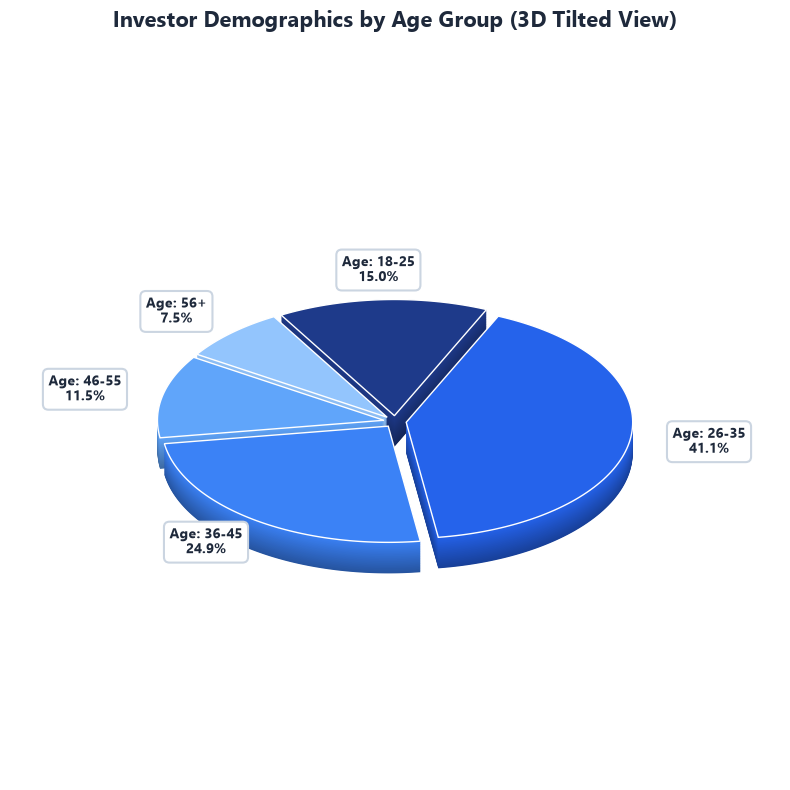

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

age_counts = investors["age_group"].value_counts().sort_index()
age_labels = list(age_counts.index)
age_values = list(age_counts.values)

age_colors = ["#1e3a8a", "#2563eb", "#3b82f6", "#60a5fa", "#93c5fd"]

def draw_tilted_3d_pie(ax, values, labels, colors, explode=None, title=""):
    values = np.array(values, dtype=float)
    pcts = values / values.sum()
    
    if explode is None:
        explode = [0.0] * len(values)
        
    r_major = 1.0
    r_minor = 0.55
    depth = 0.15
    num_layers = 50
    
    start_angle = 120
    angles = []
    current_angle = start_angle
    for pct in pcts:
        end_angle = current_angle - (pct * 360)
        angles.append((current_angle, end_angle))
        current_angle = end_angle

    # Draw stacked layers for 3D effect
    for i in range(num_layers):
        layer_offset = (i / num_layers) * depth
        is_top = (i == num_layers - 1)
        factor = 0.65 + 0.35 * (i / num_layers)
        
        for idx, (sa, ea) in enumerate(angles):
            mid_angle = np.radians((sa + ea) / 2)
            ex = explode[idx] * np.cos(mid_angle) * r_major
            ey = explode[idx] * np.sin(mid_angle) * r_minor
            
            cx = ex
            cy = ey - depth + layer_offset
            
            theta = np.linspace(np.radians(ea), np.radians(sa), 100)
            x_arc = cx + r_major * np.cos(theta)
            y_arc = cy + r_minor * np.sin(theta)
            
            vertices = np.concatenate(([cx], x_arc, [cx]))
            vertices_y = np.concatenate(([cy], y_arc, [cy]))
            poly_points = np.column_stack((vertices, vertices_y))
            
            c = colors[idx].lstrip('#')
            r, g, b = tuple(int(c[j:j+2], 16) for j in (0, 2, 4))
            
            if is_top:
                face_color = colors[idx]
                edge_color = "white"
                lw = 1.0
            else:
                face_color = f"#{int(r*factor):02x}{int(g*factor):02x}{int(b*factor):02x}"
                edge_color = "none"
                lw = 0
                
            poly = Polygon(
                poly_points,
                facecolor=face_color,
                edgecolor=edge_color,
                linewidth=lw
            )
            ax.add_patch(poly)
            
    # Labels
    for idx, (sa, ea) in enumerate(angles):
        mid_angle = np.radians((sa + ea) / 2)
        ex = explode[idx] * np.cos(mid_angle) * r_major
        ey = explode[idx] * np.sin(mid_angle) * r_minor
        
        lx = ex + 1.35 * np.cos(mid_angle) * r_major
        ly = ey + 1.25 * np.sin(mid_angle) * r_minor
        
        label_text = f"Age: {labels[idx]}\n{pcts[idx]*100:.1f}%"
        
        ax.text(
            lx, ly, label_text,
            ha="center", va="center",
            fontfamily="Segoe UI", fontsize=10, fontweight="bold",
            color="#1e293b",
            bbox=dict(boxstyle="round,pad=0.4", fc="#ffffff", ec="#cbd5e1", lw=1.5)
        )
        
    ax.set_xlim(-1.7, 1.7)
    ax.set_ylim(-1.7, 1.7)
    ax.axis("off")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=25, color="#1e293b", family="Segoe UI")

fig, ax = plt.subplots(figsize=(8, 8), facecolor="white")
draw_tilted_3d_pie(
    ax,
    values=age_values,
    labels=age_labels,
    colors=age_colors,
    explode=[0.05, 0.05, 0.05, 0.05, 0.05],
    title="Investor Demographics by Age Group (3D Tilted View)"
)

plt.tight_layout()
plt.savefig(CHARTS_DIR / "demographics.png", dpi=300)
plt.show()


## Insight 5

Investors aged **26–35 years** form the largest segment of the mutual fund investor base, accounting for a significant share of all transactions.

Participation gradually decreases in higher age groups, while investors aged **18–25 years** represent an emerging segment with strong long-term investment potential.

# 6. Geographic Distribution of SIP Investments

## Objective

To analyze the geographical distribution of mutual fund investments across different Indian states by comparing the total SIP transaction amounts. This visualization helps identify regions with higher investor participation and provides insights into the spread of mutual fund adoption across the country.

In [18]:
# Top states by transaction count
transactions["state"].value_counts().head(20)

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Rajasthan         2577
Maharashtra       2524
Name: count, dtype: int64

In [19]:
# Transaction types
transactions["transaction_type"].value_counts()

transaction_type
SIP           19716
LUMPSUM        8095
REDEMPTION     4967
Name: count, dtype: int64

In [20]:
# Filter SIP transactions
sip_state = (
    transactions[transactions["transaction_type"] == "SIP"]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

sip_state.head(10)

state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Tamil Nadu        18404368
Gujarat           18378904
Haryana           18176696
Karnataka         17696903
Uttar Pradesh     17534858
West Bengal       17495769
Delhi             17113608
Name: amount_inr, dtype: int64

In [21]:
import numpy as np
import plotly.graph_objects as go

top10 = sip_state.head(10)
states = list(top10.index)
values_m = list(top10.values / 1e6) # Convert to Millions

# Curated teal-indigo gradient
colors = [
    "#1e3a8a", # 1
    "#23449b", # 2
    "#274fad", # 3
    "#2c5abe", # 4
    "#1072b4", # 5
    "#0d85ab", # 6
    "#0a98a2", # 7
    "#06ab99", # 8
    "#02be90", # 9
    "#05c47c"  # 10
]

# We want Rank 1 to be on top, so we reverse the list for Plotly y-axis ordering
states_rev = states[::-1]
values_m_rev = values_m[::-1]
colors_rev = colors[::-1]
ranks_rev = list(range(10, 0, -1))

fig = go.Figure(data=go.Bar(
    y=states_rev,
    x=values_m_rev,
    orientation="h",
    marker=dict(
        color=colors_rev,
        line=dict(color="#ffffff", width=1.5)
    ),
    text=[f"<b>#{r}</b> | ₹{val:.1f}M" for r, val in zip(ranks_rev, values_m_rev)],
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(color="white", size=11, family="Segoe UI, Helvetica, Arial"),
    width=0.65
))

fig.update_layout(
    template="plotly_white",
    width=900,
    height=600,
    title={
        "text": "<b>Top 10 States by SIP Investment Volume</b><br><span style='font-size:12px;color:#64748b;'>Ranked by total systematic investment plan contributions (INR Millions)</span>",
        "y": 0.95,
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 18, "color": "#1e293b", "family": "Segoe UI, Helvetica, Arial"}
    },
    xaxis=dict(
        title="SIP Investment Volume (₹ Millions)",
        showgrid=True,
        gridcolor="#f1f5f9",
        tickfont=dict(color="#475569")
    ),
    yaxis=dict(
        tickfont=dict(size=12, color="#1e293b", family="Segoe UI, Helvetica, Arial", weight="bold"),
        showgrid=False
    ),
    margin=dict(t=100, b=80, l=150, r=80)
)

fig.show()
fig.write_image(CHARTS_DIR / "state_distribution.png", scale=2)
print("state_distribution.png saved successfully")


state_distribution.png saved successfully


## Insight 6

States with higher SIP transaction volumes contribute a significant portion of the overall mutual fund investments, indicating stronger retail participation and greater financial awareness in these regions.

The distribution also suggests that mutual fund investments are concentrated in a few major states, while several regions still have considerable growth potential for expanding investor participation.

# 7. T30 vs B30 City Tier Distribution

## Objective

To examine the distribution of mutual fund investments between Top 30 (T30) cities and Beyond Top 30 (B30) cities. This analysis helps evaluate the concentration of investor participation in metropolitan regions compared to emerging markets across the country.

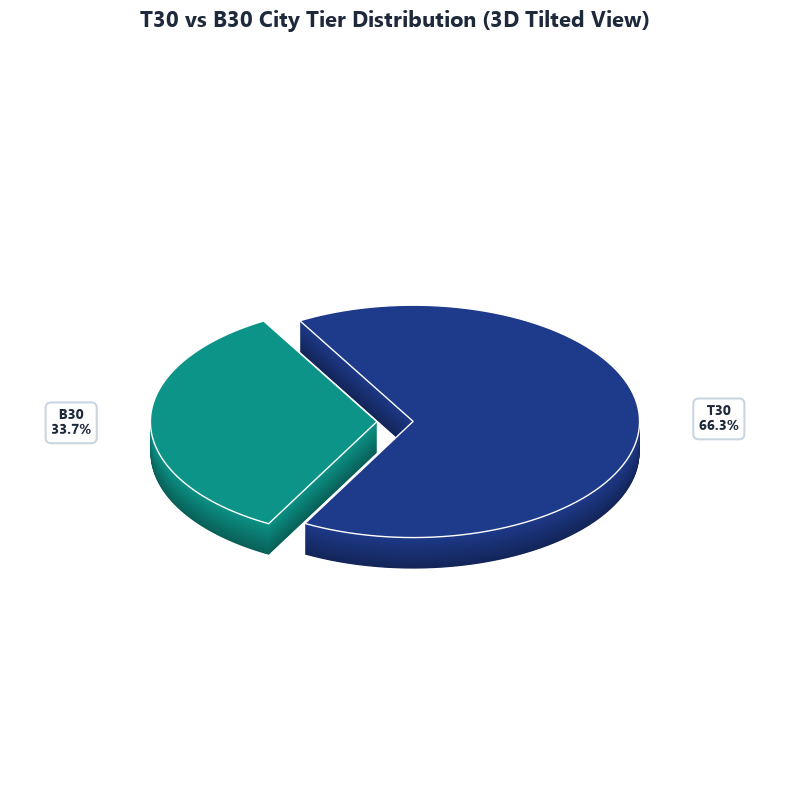

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

city_tier_counts = transactions["city_tier"].value_counts()
city_labels = list(city_tier_counts.index)
city_values = list(city_tier_counts.values)
city_colors = ["#1e3a8a", "#0d9488"]

def draw_tilted_3d_pie(ax, values, labels, colors, explode=None, title=""):
    values = np.array(values, dtype=float)
    pcts = values / values.sum()
    
    if explode is None:
        explode = [0.0] * len(values)
        
    r_major = 1.0
    r_minor = 0.55
    depth = 0.15
    num_layers = 50
    
    start_angle = 120
    angles = []
    current_angle = start_angle
    for pct in pcts:
        end_angle = current_angle - (pct * 360)
        angles.append((current_angle, end_angle))
        current_angle = end_angle

    # Draw stacked layers for 3D effect
    for i in range(num_layers):
        layer_offset = (i / num_layers) * depth
        is_top = (i == num_layers - 1)
        factor = 0.65 + 0.35 * (i / num_layers)
        
        for idx, (sa, ea) in enumerate(angles):
            mid_angle = np.radians((sa + ea) / 2)
            ex = explode[idx] * np.cos(mid_angle) * r_major
            ey = explode[idx] * np.sin(mid_angle) * r_minor
            
            cx = ex
            cy = ey - depth + layer_offset
            
            theta = np.linspace(np.radians(ea), np.radians(sa), 100)
            x_arc = cx + r_major * np.cos(theta)
            y_arc = cy + r_minor * np.sin(theta)
            
            vertices = np.concatenate(([cx], x_arc, [cx]))
            vertices_y = np.concatenate(([cy], y_arc, [cy]))
            poly_points = np.column_stack((vertices, vertices_y))
            
            c = colors[idx].lstrip('#')
            r, g, b = tuple(int(c[j:j+2], 16) for j in (0, 2, 4))
            
            if is_top:
                face_color = colors[idx]
                edge_color = "white"
                lw = 1.0
            else:
                face_color = f"#{int(r*factor):02x}{int(g*factor):02x}{int(b*factor):02x}"
                edge_color = "none"
                lw = 0
                
            poly = Polygon(
                poly_points,
                facecolor=face_color,
                edgecolor=edge_color,
                linewidth=lw
            )
            ax.add_patch(poly)
            
    # Labels
    for idx, (sa, ea) in enumerate(angles):
        mid_angle = np.radians((sa + ea) / 2)
        ex = explode[idx] * np.cos(mid_angle) * r_major
        ey = explode[idx] * np.sin(mid_angle) * r_minor
        
        lx = ex + 1.35 * np.cos(mid_angle) * r_major
        ly = ey + 1.25 * np.sin(mid_angle) * r_minor
        
        label_text = f"{labels[idx]}\n{pcts[idx]*100:.1f}%"
        
        ax.text(
            lx, ly, label_text,
            ha="center", va="center",
            fontfamily="Segoe UI", fontsize=10, fontweight="bold",
            color="#1e293b",
            bbox=dict(boxstyle="round,pad=0.4", fc="#ffffff", ec="#cbd5e1", lw=1.5)
        )
        
    ax.set_xlim(-1.7, 1.7)
    ax.set_ylim(-1.7, 1.7)
    ax.axis("off")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=25, color="#1e293b", family="Segoe UI")

fig, ax = plt.subplots(figsize=(8, 8), facecolor="white")
draw_tilted_3d_pie(
    ax,
    values=city_values,
    labels=city_labels,
    colors=city_colors,
    explode=[0.08, 0.08],
    title="T30 vs B30 City Tier Distribution (3D Tilted View)"
)

plt.tight_layout()
plt.savefig(CHARTS_DIR / "city_tier_distribution.png", dpi=300)
plt.show()


## Insight 7

A significant share of mutual fund transactions originates from Top 30 (T30) cities, highlighting the stronger penetration of mutual fund investments in metropolitan regions.

At the same time, Beyond Top 30 (B30) cities contribute a meaningful portion of total investments, indicating growing financial awareness and expanding mutual fund adoption in emerging markets across India.

## 8. Folio Count Growth

### Objective

To visualize the growth in mutual fund folio accounts between January 2022 and December 2025. The chart highlights the increasing participation of retail investors by showing the steady rise in folio count and marking important milestones during the period.

In [23]:
import plotly.graph_objects as go

labels = ["Jan 2022 Base", "2023 Additions", "2024 Additions", "2025 Additions", "Dec 2025 Total"]
heights = [13.26, 4.19, 5.39, 3.28, 26.12]
bottoms = [0, 13.26, 17.45, 22.84, 0]
colors = ["#1e3a8a", "#0d9488", "#0d9488", "#0d9488", "#1e3a8a"]  # Navy for totals, Teal for increments
text_labels = ["13.26 Cr", "+4.19 Cr", "+5.39 Cr", "+3.28 Cr", "26.12 Cr"]

fig = go.Figure()

# Add customized Bar trace
fig.add_trace(go.Bar(
    x=labels,
    y=heights,
    base=bottoms,
    marker=dict(
        color=colors,
        line=dict(color="#ffffff", width=1.5)
    ),
    text=text_labels,
    textposition="outside",
    textfont=dict(family="Segoe UI, Helvetica, Arial", size=12, color="#1e293b", weight="bold"),
    width=0.55,
    hovertemplate="<b>%{x}</b><br>Value: %{text}<extra></extra>"
))

# Draw connection lines between bars
cums = [13.26, 17.45, 22.84, 26.12, 26.12]
for i in range(len(labels) - 1):
    fig.add_shape(
        type="line",
        x0=i + 0.275,
        y0=cums[i],
        x1=i + 0.725,
        y1=cums[i],
        line=dict(color="#94a3b8", width=1.5, dash="dash"),
        xref="x",
        yref="y"
    )

fig.update_layout(
    template="plotly_white",
    width=800,
    height=550,
    title={
        "text": "<b>Growth in Mutual Fund Folio Accounts (2022–2025)</b><br><span style='font-size:12px;color:#64748b;'>Waterfall chart showing year-over-year additions and baseline totals (Crores)</span>",
        "y": 0.94,
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 16, "color": "#1e293b", "family": "Segoe UI, Helvetica, Arial"}
    },
    yaxis=dict(
        title="Folio Count (Crore)",
        range=[0, 30.0],
        showgrid=True,
        gridcolor="#f1f5f9",
        tickfont=dict(color="#475569")
    ),
    xaxis=dict(
        tickfont=dict(color="#475569"),
        showgrid=False
    ),
    margin=dict(t=100, b=50, l=60, r=60)
)

fig.show()
fig.write_image(CHARTS_DIR / "folio_growth.png", scale=2)
print("folio_growth.png saved successfully")


folio_growth.png saved successfully


## Insight 8

Mutual fund folio accounts nearly doubled from **13.26 crore** in January 2022 to **26.12 crore** in December 2025, reflecting strong growth in retail investor participation.

The consistent upward trend indicates increasing investor confidence, wider financial awareness, and continued expansion of mutual fund adoption across India.

In [24]:
nav.columns.tolist()

['amfi_code', 'date', 'nav']

In [25]:
portfolio.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

## 9. NAV Return Correlation Matrix

### Objective

To analyze the relationship between the daily returns of selected mutual fund schemes by computing a correlation matrix. This visualization helps identify funds with similar performance patterns and provides insights into portfolio diversification opportunities.

In [26]:
import seaborn as sns
import numpy as np
import plotly.graph_objects as go

# Prepare NAV data
nav_df = nav.copy()
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Select first 10 schemes
selected_funds = nav_df["amfi_code"].unique()[:10]
nav_selected = nav_df[nav_df["amfi_code"].isin(selected_funds)]

# Create NAV table
nav_pivot = nav_selected.pivot(index="date", columns="amfi_code", values="nav")

# Correlation Matrix
corr_matrix = nav_pivot.corr()
cols = [str(col) for col in corr_matrix.columns]
corr_values = corr_matrix.values

n = len(cols)
z_masked = []
text_masked = []

for r_idx in range(n):
    z_row = []
    text_row = []
    for c_idx in range(n):
        if r_idx > c_idx:
            val = corr_values[r_idx, c_idx]
            z_row.append(val)
            color = "white" if val > 0.85 else "#334155"
            text_row.append(f"<span style='color: {color}; font-weight: bold;'>{val:.2f}</span>")
        else:
            z_row.append(None)
            text_row.append("")
    z_masked.append(z_row)
    text_masked.append(text_row)

# Custom colorscale: Slate grey to deep blue
colorscale = [
    [0.0, '#f8fafc'],
    [0.2, '#dbeafe'],
    [0.5, '#60a5fa'],
    [0.8, '#2563eb'],
    [1.0, '#1e3a8a']
]

fig = go.Figure(data=go.Heatmap(
    z=z_masked,
    x=cols,
    y=cols,
    text=text_masked,
    texttemplate="%{text}",
    textfont={"size": 11, "family": "Segoe UI, Helvetica, Arial"},
    colorscale=colorscale,
    zmin=0.3,
    zmax=1.0,
    showscale=True,
    colorbar=dict(
        title=dict(text="Correlation Coefficient", side="right"),
        thickness=15,
        len=0.8
    ),
    xgap=2,
    ygap=2
))

fig.update_layout(
    template="plotly_white",
    width=800,
    height=700,
    title={
        "text": "<b>Pairwise NAV Return Correlation Matrix</b><br><span style='font-size:12px;color:#64748b;'>Lower-triangular matrix showing relationships between top 10 schemes</span>",
        "y": 0.95,
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 16, "color": "#1e293b", "family": "Segoe UI, Helvetica, Arial"}
    },
    xaxis=dict(
        showgrid=False,
        tickangle=45,
        side="bottom"
    ),
    yaxis=dict(
        showgrid=False,
        autorange="reversed"
    ),
    margin=dict(t=100, b=80, l=100, r=80)
)

fig.show()
fig.write_image(CHARTS_DIR / "correlation.png", scale=2)
print("correlation.png saved successfully")


correlation.png saved successfully


## Insight 9

Several mutual fund schemes exhibit strong positive correlations in their daily returns, indicating similar market behaviour and investment strategies.

The correlation matrix also highlights opportunities for portfolio diversification by identifying schemes with comparatively lower correlations.

## 10. Sector Allocation Across Equity Funds

### Objective

To examine the overall sector allocation of equity mutual funds by aggregating portfolio holdings. This visualization highlights the sectors receiving the highest investment allocation and provides an overview of portfolio diversification across industries.

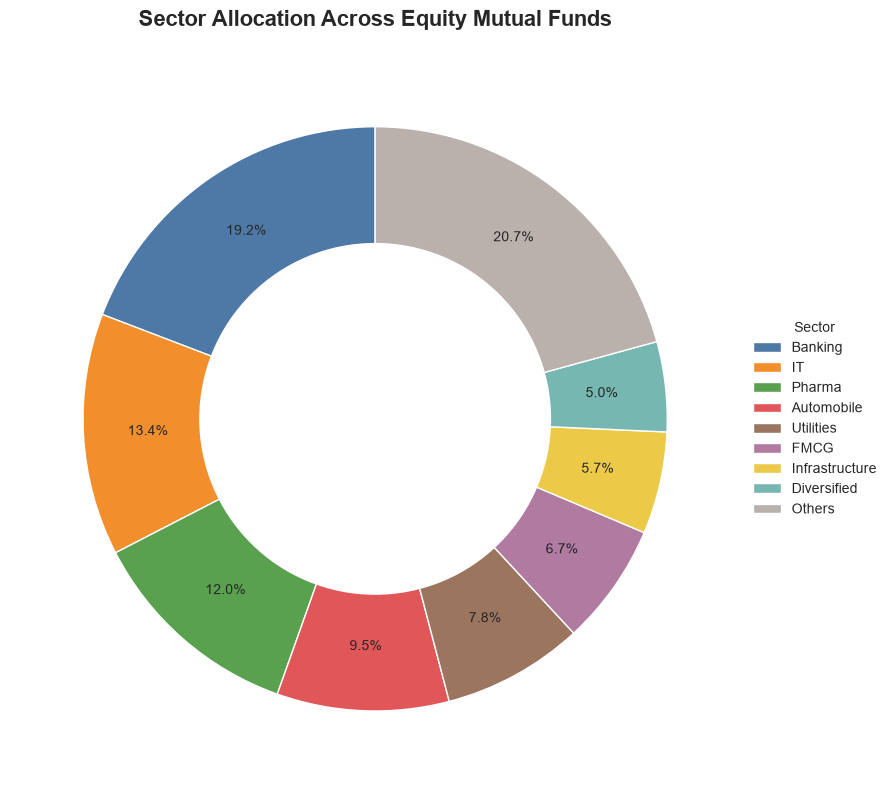

✅ sector_donut.png saved


In [27]:
# Aggregate sector weights
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Keep Top 8 sectors
top8 = sector_weights.head(8)
others = sector_weights.iloc[8:].sum()

sector_plot = pd.concat([
    top8,
    pd.Series({"Others": others})
])

plt.figure(figsize=(9,9))

colors = [
    "#4E79A7",
    "#F28E2B",
    "#59A14F",
    "#E15759",
    "#9C755F",
    "#B07AA1",
    "#EDC948",
    "#76B7B2",
    "#BAB0AC"
]

wedges, _, autotexts = plt.pie(
    sector_plot,
    labels=None,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 4 else "",
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white")
)

plt.legend(
    wedges,
    sector_plot.index,
    title="Sector",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
# Center circle
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)

plt.title(
    "Sector Allocation Across Equity Mutual Funds",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(CHARTS_DIR / "sector_donut.png", dpi=300)

plt.show()

print("✅ sector_donut.png saved")

## Insight 10

The portfolio allocation is concentrated across a few key sectors, reflecting the investment priorities of equity mutual funds.

A diversified sector allocation helps balance growth opportunities with risk management while maintaining exposure to different segments of the economy.

# Final EDA Findings

### 1. NAV Trends (Chart 1)
Daily NAV values showed a steady upward trend across most mutual fund schemes, with strong recovery after 2022 and sustained growth during 2023.

### 2. AUM Growth (Chart 2)
SBI Mutual Fund maintained the highest Assets Under Management throughout the observed period, reflecting its market leadership.

### 3. SIP Inflow Trend (Chart 3)
Monthly SIP inflows increased consistently and reached an all-time high of ₹31,002 crore in December 2025, indicating rising retail investor participation.

### 4. Category-wise Inflows (Chart 4)
Equity-oriented categories attracted the highest net inflows, while debt and liquid categories experienced comparatively lower investor interest.

### 5. Investor Demographics (Chart 5)
The 26–35 years age group accounted for the largest share of investors, indicating strong participation from young working professionals.

### 6. Geographic Distribution (Chart 6)
States such as Punjab, Madhya Pradesh, Tamil Nadu and Gujarat recorded the highest transaction volumes, showing broad geographical participation.

### 7. City Tier Distribution (Chart 7)
Tier-2 and Tier-3 cities contributed significantly to mutual fund investments, highlighting increasing adoption beyond metropolitan regions.

### 8. Folio Growth (Chart 8)
Industry folio counts nearly doubled during the analysis period, reflecting rapid expansion of India's mutual fund investor base.

### 9. NAV Return Correlation (Chart 9)
Most large-cap mutual funds exhibited positive return correlations, suggesting similar performance patterns under common market conditions.

### 10. Sector Allocation (Chart 10)
Portfolio allocations were concentrated in Banking, IT and Pharma sectors, indicating a preference for sectors with strong long-term growth potential.